In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/data/processed/paysim_cleaned.csv')

In [4]:
print(f"Shape: {df.shape}")
print("Libraries and data loaded!")

Shape: (6362620, 14)
Libraries and data loaded!


In [5]:
# Global style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Color palette
FRAUD_COLOR = '#e74c3c'
LEGIT_COLOR = '#2980b9'
ACCENT = '#f39c12'

print("Style set!")

Style set!


C:\Users\aryan\AppData\Local\Temp\ipykernel_20996\2074081350.py:51: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart1_transaction_overview.png',
C:\Users\aryan\AppData\Local\Temp\ipykernel_20996\2074081350.py:51: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart1_transaction_overview.png',
C:\Users\aryan\AppData\Local\Temp\ipykernel_20996\2074081350.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart1_transaction_overview.png',
C:\Users\aryan\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, 

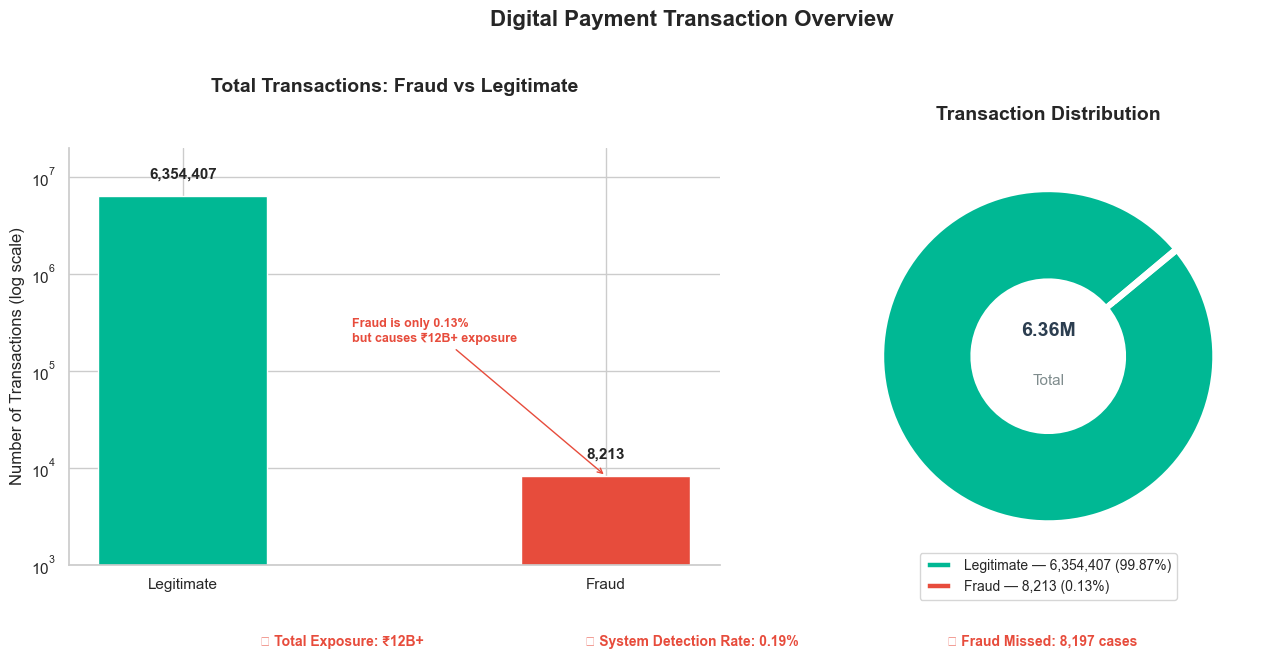

Chart 1 saved!


In [6]:
# Chart 1 - Final polished version
LEGIT_COLOR = '#00b894'
FRAUD_COLOR = '#e74c3c'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left - log scale bar
values = [6354407, 8213]
bars = axes[0].bar(['Legitimate', 'Fraud'], values, color=[LEGIT_COLOR, FRAUD_COLOR], width=0.4)
axes[0].set_title('Total Transactions: Fraud vs Legitimate', pad=40)
axes[0].set_ylabel('Number of Transactions (log scale)')
axes[0].set_yscale('log')
axes[0].set_ylim(1000, 20000000)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Annotation positioned lower so it doesn't hit title
axes[0].annotate('Fraud is only 0.13%\nbut causes ₹12B+ exposure',
                xy=(1, 8213), xytext=(0.4, 200000),
                fontsize=9, color=FRAUD_COLOR, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR))

# Right - donut with BOTH colors clearly visible
sizes = [6354407, 8213]
explode = (0, 0.08)
wedges, _ = axes[1].pie(
    sizes, colors=[LEGIT_COLOR, FRAUD_COLOR],
    explode=explode, startangle=40,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=4))
axes[1].set_title('Transaction Distribution', pad=20)
axes[1].text(0, 0.15, '6.36M', ha='center', va='center',
             fontsize=14, fontweight='bold', color='#2c3e50')
axes[1].text(0, -0.15, 'Total', ha='center', va='center',
             fontsize=11, color='#7f8c8d')
axes[1].legend(wedges,
               ['Legitimate — 6,354,407 (99.87%)', 'Fraud — 8,213 (0.13%)'],
               loc='lower center', bbox_to_anchor=(0.5, -0.1), fontsize=10)

fig.suptitle('Digital Payment Transaction Overview', fontsize=16, fontweight='bold', y=1.02)

# Add KPI row at bottom
fig.text(0.25, -0.04, '💰 Total Exposure: ₹12B+', ha='center', fontsize=10, 
         color=FRAUD_COLOR, fontweight='bold')
fig.text(0.5, -0.04, '🚨 System Detection Rate: 0.19%', ha='center', fontsize=10,
         color=FRAUD_COLOR, fontweight='bold')
fig.text(0.75, -0.04, '📊 Fraud Missed: 8,197 cases', ha='center', fontsize=10,
         color=FRAUD_COLOR, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart1_transaction_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

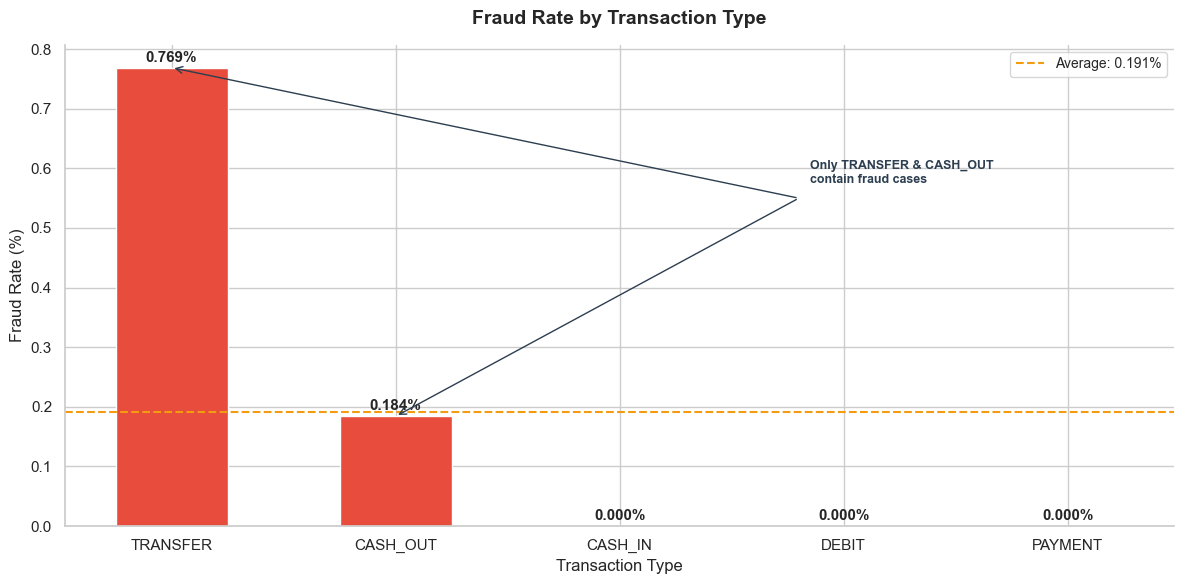

Chart 2 saved!


In [7]:
# Chart 2 - Final version
fig, ax = plt.subplots(figsize=(12, 6))

fraud_by_type = df.groupby('type')['is_fraud'].mean() * 100
fraud_by_type = fraud_by_type.sort_values(ascending=False)
colors_bar = [FRAUD_COLOR, FRAUD_COLOR, '#bdc3c7', '#bdc3c7', '#bdc3c7']

bars = ax.bar(fraud_by_type.index, fraud_by_type.values, color=colors_bar, width=0.5)
ax.set_title('Fraud Rate by Transaction Type', pad=15)
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('Transaction Type')

# Average line
avg = fraud_by_type.mean()
ax.axhline(y=avg, color='#f39c12', linestyle='--', linewidth=1.5, label=f'Average: {avg:.3f}%')
ax.legend(fontsize=10)

for bar, v in zip(bars, fraud_by_type.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}%', ha='center', fontweight='bold', fontsize=11)

# Two arrows merging into one text
ax.annotate('', xy=(0, 0.769), xytext=(2.8, 0.55),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'))
ax.annotate('', xy=(1, 0.184), xytext=(2.8, 0.55),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'))
ax.text(2.85, 0.57, 'Only TRANSFER & CASH_OUT\ncontain fraud cases',
        fontsize=9, color='#2c3e50', fontweight='bold', va='bottom')

plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart2_fraud_by_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

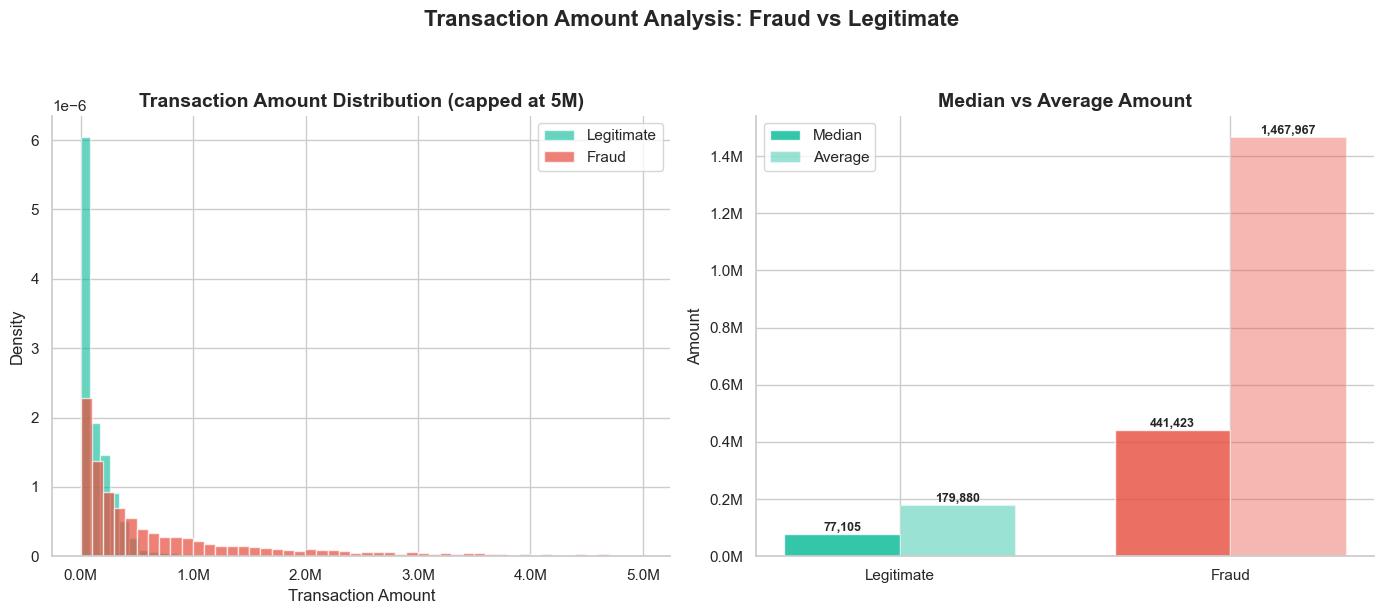

Chart 3 saved!


In [8]:
# Chart 3 - Fixed with capped axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fraud_amounts = df[df['is_fraud']==1]['amount']
legit_amounts = df[df['is_fraud']==0]['amount'].sample(10000, random_state=42)

# Left - capped at 5M so distribution is visible
axes[0].hist(legit_amounts[legit_amounts < 5000000], bins=50, 
             color=LEGIT_COLOR, alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud_amounts[fraud_amounts < 5000000], bins=50, 
             color=FRAUD_COLOR, alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution (capped at 5M)')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Right - median comparison bar chart instead of boxplot
medians = pd.DataFrame({
    'Category': ['Legitimate', 'Fraud'],
    'Median Amount': [legit_amounts.median(), fraud_amounts.median()],
    'Average Amount': [legit_amounts.mean(), fraud_amounts.mean()]
})

x = range(2)
width = 0.35
axes[1].bar([i - width/2 for i in x], medians['Median Amount'], 
            width, label='Median', color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.8)
axes[1].bar([i + width/2 for i in x], medians['Average Amount'], 
            width, label='Average', color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_title('Median vs Average Amount')
axes[1].set_ylabel('Amount')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for i, (med, avg) in enumerate(zip(medians['Median Amount'], medians['Average Amount'])):
    axes[1].text(i - width/2, med + 10000, f'{med:,.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, avg + 10000, f'{avg:,.0f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Transaction Amount Analysis: Fraud vs Legitimate', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart3_amount_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

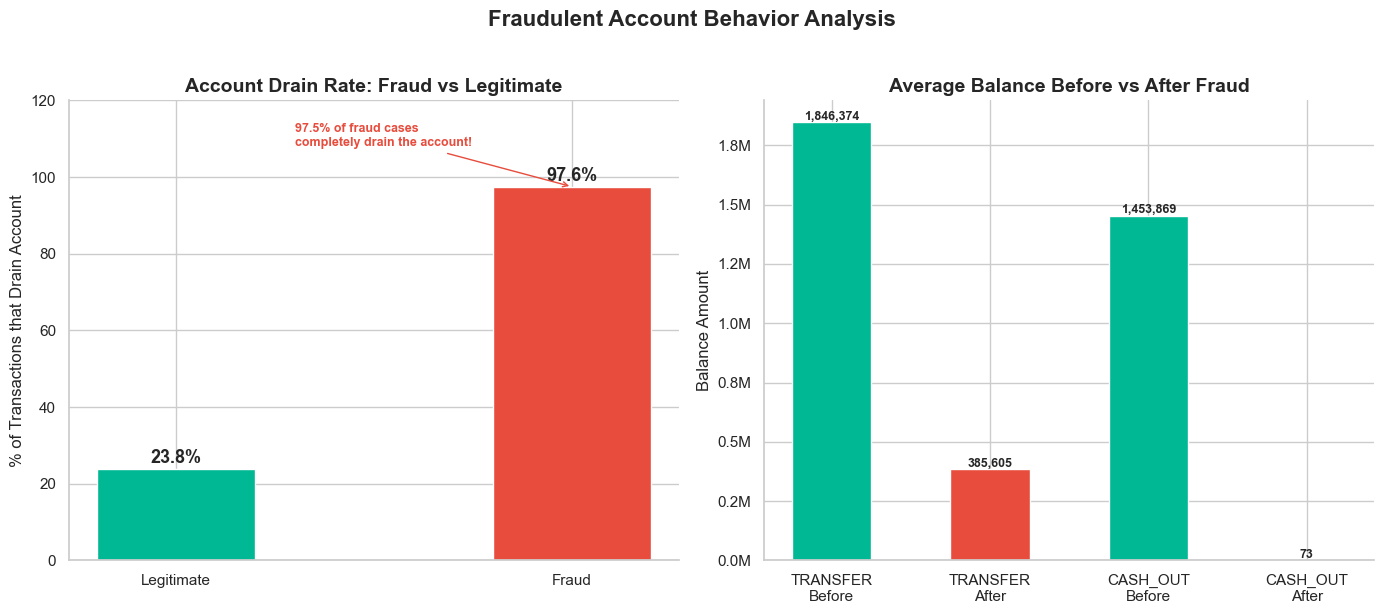

Chart 4 saved!


In [9]:
# Chart 4 - Account Draining Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left - drain rate comparison
drain_data = df.groupby('is_fraud')['is_fully_drained'].mean() * 100
bars = axes[0].bar(['Legitimate', 'Fraud'], drain_data.values, 
                    color=[LEGIT_COLOR, FRAUD_COLOR], width=0.4)
axes[0].set_title('Account Drain Rate: Fraud vs Legitimate')
axes[0].set_ylabel('% of Transactions that Drain Account')
axes[0].set_ylim(0, 120)
for bar, v in zip(bars, drain_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)

axes[0].annotate('97.5% of fraud cases\ncompletely drain the account!',
                xy=(1, 97.5), xytext=(0.3, 108),
                fontsize=9, color=FRAUD_COLOR, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR))

# Right - balance before vs after for fraud
fraud_df = df[df['is_fraud']==1]
balance_data = pd.DataFrame({
    'Type': ['TRANSFER\nBefore', 'TRANSFER\nAfter', 'CASH_OUT\nBefore', 'CASH_OUT\nAfter'],
    'Balance': [
        fraud_df[fraud_df['type']=='TRANSFER']['old_balance_orig'].mean(),
        fraud_df[fraud_df['type']=='TRANSFER']['new_balance_orig'].mean(),
        fraud_df[fraud_df['type']=='CASH_OUT']['old_balance_orig'].mean(),
        fraud_df[fraud_df['type']=='CASH_OUT']['new_balance_orig'].mean()
    ],
    'Color': [LEGIT_COLOR, FRAUD_COLOR, LEGIT_COLOR, FRAUD_COLOR]
})

bars2 = axes[1].bar(balance_data['Type'], balance_data['Balance'], 
                     color=balance_data['Color'], width=0.5)
axes[1].set_title('Average Balance Before vs After Fraud')
axes[1].set_ylabel('Balance Amount')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, v in zip(bars2, balance_data['Balance']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
                f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)

fig.suptitle('Fraudulent Account Behavior Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart4_account_draining.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

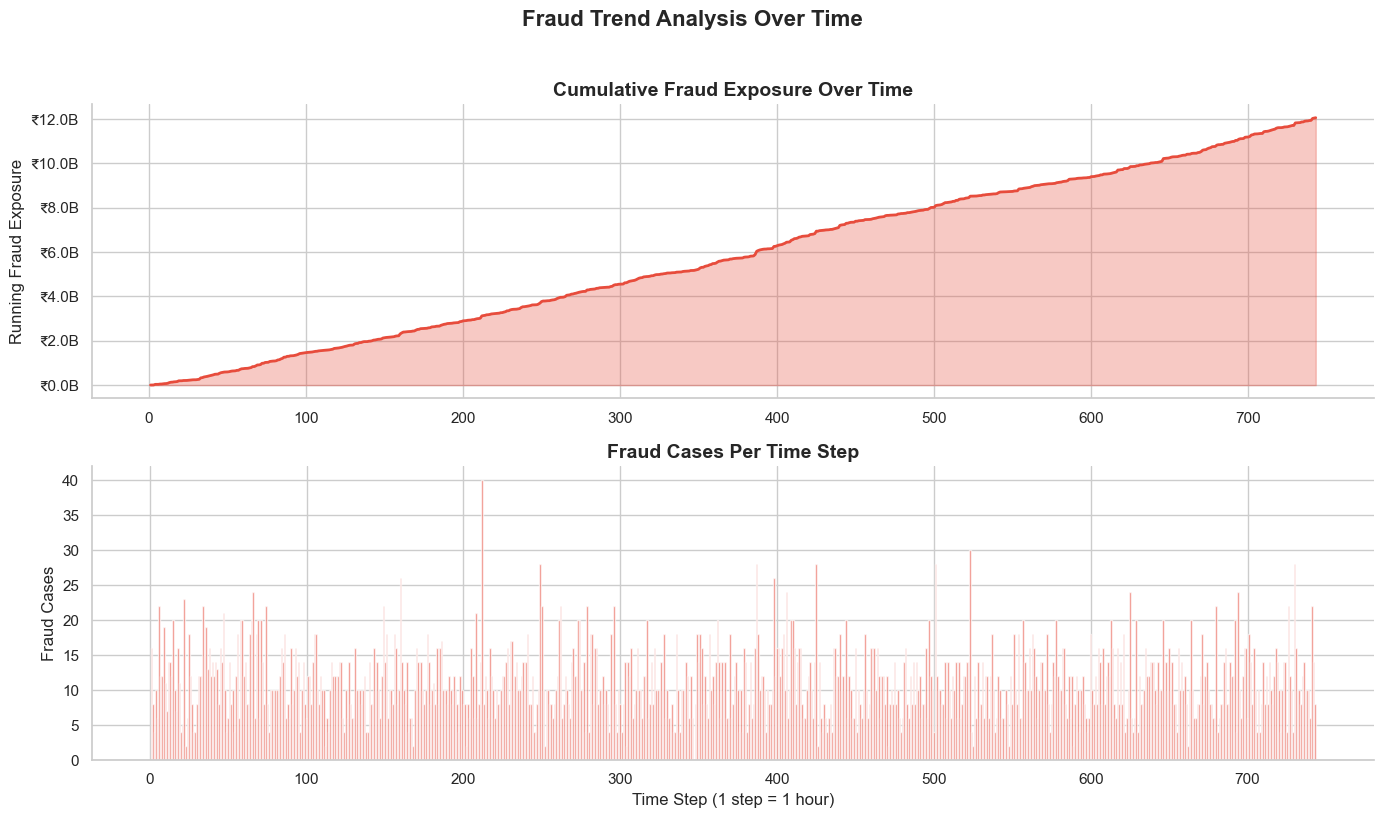

Chart 5 saved!


In [10]:
# Chart 5 - Running Fraud Exposure Over Time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Aggregate by step
step_data = df.groupby('step').agg(
    fraud_count=('is_fraud', 'sum'),
    fraud_exposure=('amount', lambda x: x[df.loc[x.index, 'is_fraud']==1].sum())
).reset_index()

step_data['running_exposure'] = step_data['fraud_exposure'].cumsum()
step_data['running_count'] = step_data['fraud_count'].cumsum()

# Top - running exposure line
axes[0].fill_between(step_data['step'], step_data['running_exposure'], 
                      alpha=0.3, color=FRAUD_COLOR)
axes[0].plot(step_data['step'], step_data['running_exposure'], 
             color=FRAUD_COLOR, linewidth=2)
axes[0].set_title('Cumulative Fraud Exposure Over Time')
axes[0].set_ylabel('Running Fraud Exposure')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e9:.1f}B'))

# Bottom - fraud count per step
axes[1].bar(step_data['step'], step_data['fraud_count'], 
            color=FRAUD_COLOR, alpha=0.7, width=1.0)
axes[1].set_title('Fraud Cases Per Time Step')
axes[1].set_xlabel('Time Step (1 step = 1 hour)')
axes[1].set_ylabel('Fraud Cases')

fig.suptitle('Fraud Trend Analysis Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart5_fraud_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

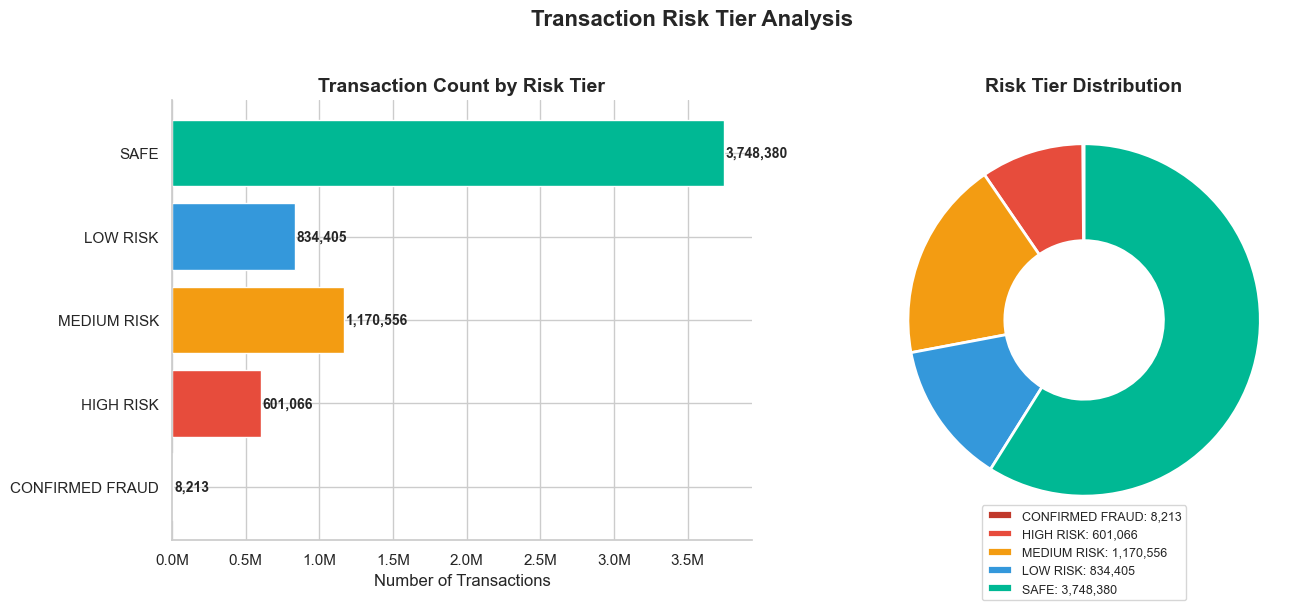

Chart 6 saved!


In [11]:
# Chart 6 - Risk Tier Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create risk tiers
def assign_risk(row):
    if row['is_fraud'] == 1:
        return 'CONFIRMED FRAUD'
    elif row['type'] in ['TRANSFER', 'CASH_OUT'] and row['amount'] > 500000 and row['is_fully_drained'] == 1:
        return 'HIGH RISK'
    elif row['type'] in ['TRANSFER', 'CASH_OUT'] and row['amount'] > 200000 and row['is_fully_drained'] == 1:
        return 'HIGH RISK'
    elif row['type'] in ['TRANSFER', 'CASH_OUT'] and row['amount'].between(100000,500000):
        return 'MEDIUM RISK'
    elif row['type'] in ['TRANSFER', 'CASH_OUT'] and row['amount'] < 100000:
        return 'LOW RISK'
    else:
        return 'SAFE'

# Faster vectorized version
conditions = [
    df['is_fraud'] == 1,
    (df['type'].isin(['TRANSFER','CASH_OUT'])) & (df['amount'] > 200000) & (df['is_fully_drained'] == 1),
    (df['type'].isin(['TRANSFER','CASH_OUT'])) & (df['amount'].between(100000, 500000)),
    (df['type'].isin(['TRANSFER','CASH_OUT'])) & (df['amount'] < 100000)
]
choices = ['CONFIRMED FRAUD', 'HIGH RISK', 'MEDIUM RISK', 'LOW RISK']
df['risk_tier'] = np.select(conditions, choices, default='SAFE')

risk_counts = df['risk_tier'].value_counts()
tier_order = ['CONFIRMED FRAUD', 'HIGH RISK', 'MEDIUM RISK', 'LOW RISK', 'SAFE']
risk_counts = risk_counts.reindex(tier_order)

tier_colors = ['#c0392b', '#e74c3c', '#f39c12', '#3498db', '#00b894']

# Left - horizontal bar
axes[0].barh(tier_order, risk_counts.values, color=tier_colors)
axes[0].set_title('Transaction Count by Risk Tier')
axes[0].set_xlabel('Number of Transactions')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(risk_counts.values):
    axes[0].text(v + 10000, i, f'{v:,}', va='center', fontweight='bold', fontsize=10)

# Right - donut
wedges, _ = axes[1].pie(risk_counts.values, colors=tier_colors,
                         startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
axes[1].set_title('Risk Tier Distribution')
axes[1].legend(wedges, [f'{t}: {v:,}' for t, v in zip(tier_order, risk_counts.values)],
               loc='lower center', bbox_to_anchor=(0.5, -0.15), fontsize=9)

fig.suptitle('Transaction Risk Tier Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart6_risk_tiers.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

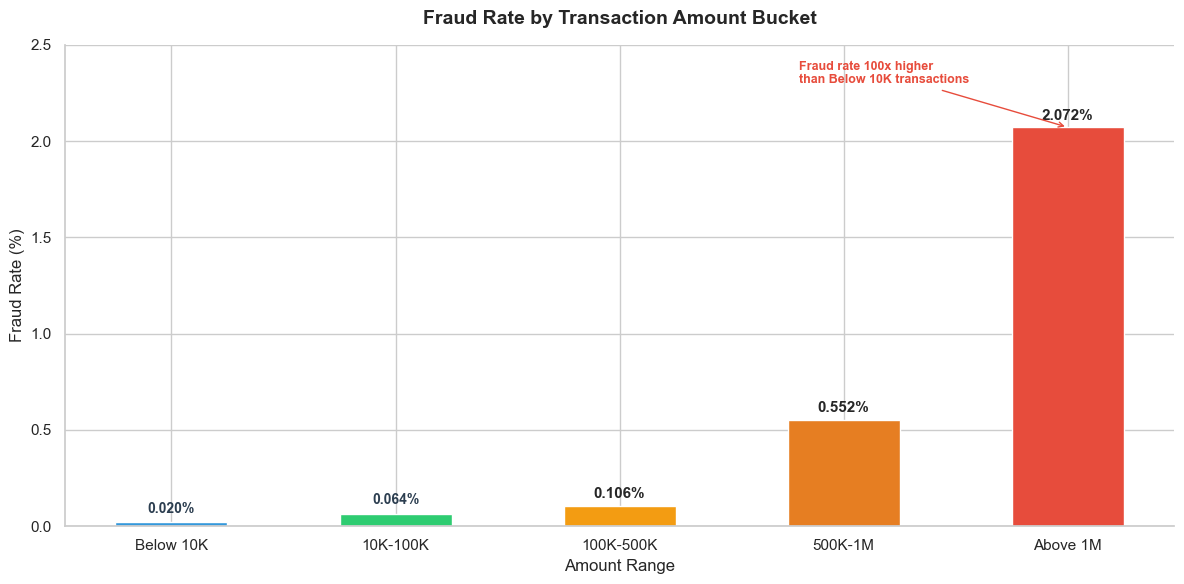

Chart 7 saved!


In [13]:
# Chart 7 - Fixed
fig, ax = plt.subplots(figsize=(12, 6))

bucket_data = pd.cut(df['amount'], 
                      bins=[0, 10000, 100000, 500000, 1000000, float('inf')],
                      labels=['Below 10K', '10K-100K', '100K-500K', '500K-1M', 'Above 1M'])

bucket_fraud = df.groupby(bucket_data)['is_fraud'].agg(['sum', 'mean']).reset_index()
bucket_fraud.columns = ['bucket', 'fraud_count', 'fraud_rate']
bucket_fraud['fraud_rate'] = bucket_fraud['fraud_rate'] * 100

colors_bucket = ['#3498db', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(bucket_fraud['bucket'], bucket_fraud['fraud_rate'], 
              color=colors_bucket, width=0.5)
ax.set_title('Fraud Rate by Transaction Amount Bucket', pad=15)
ax.set_xlabel('Amount Range')
ax.set_ylabel('Fraud Rate (%)')
ax.set_ylim(0, 2.5)

for bar, v in zip(bars, bucket_fraud['fraud_rate']):
    if v < 0.1:
        # Put label above for tiny bars
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
                f'{v:.3f}%', ha='center', fontweight='bold', fontsize=10, color='#2c3e50')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                f'{v:.3f}%', ha='center', fontweight='bold', fontsize=11)

# Fixed annotation pointing to Above 1M bar
ax.annotate('Fraud rate 100x higher\nthan Below 10K transactions',
            xy=(4, 2.072), xytext=(2.8, 2.3),
            fontsize=9, color=FRAUD_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR))

plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart7_amount_buckets.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

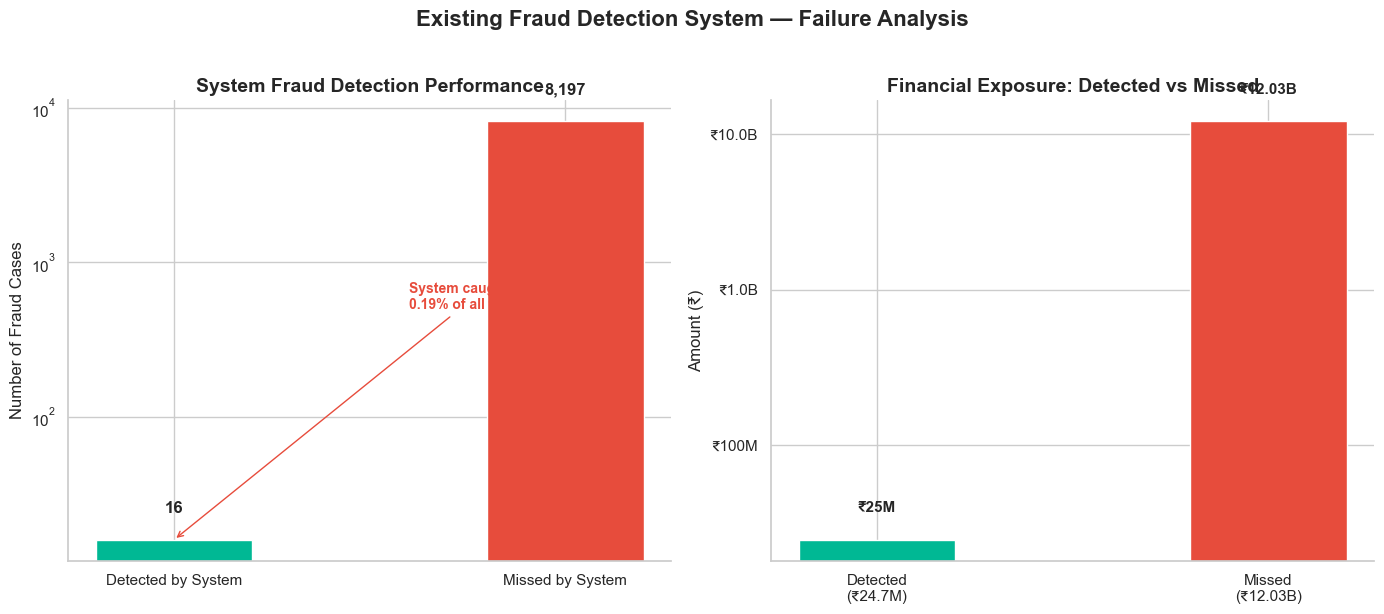

Chart 8 saved!


In [14]:
# Chart 8 - System Detection Failure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left - detected vs missed
categories = ['Detected by System', 'Missed by System']
values = [16, 8197]
colors_det = [LEGIT_COLOR, FRAUD_COLOR]
bars = axes[0].bar(categories, values, color=colors_det, width=0.4)
axes[0].set_title('System Fraud Detection Performance')
axes[0].set_ylabel('Number of Fraud Cases')
axes[0].set_yscale('log')
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                f'{v:,}', ha='center', fontweight='bold', fontsize=12)

axes[0].annotate('System caught only\n0.19% of all fraud!',
                xy=(0, 16), xytext=(0.6, 500),
                fontsize=10, color=FRAUD_COLOR, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR))

# Right - financial impact
fin_categories = ['Detected\n(₹24.7M)', 'Missed\n(₹12.03B)']
fin_values = [24700000, 12031715427]
bars2 = axes[1].bar(fin_categories, fin_values, color=colors_det, width=0.4)
axes[1].set_title('Financial Exposure: Detected vs Missed')
axes[1].set_ylabel('Amount (₹)')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e9:.1f}B' if x >= 1e9 else f'₹{x/1e6:.0f}M'))
for bar, v in zip(bars2, fin_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                f'₹{v/1e6:,.0f}M' if v < 1e9 else f'₹{v/1e9:.2f}B',
                ha='center', fontweight='bold', fontsize=11)

fig.suptitle('Existing Fraud Detection System — Failure Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/aryan/OneDrive/Desktop/Digital Payment Fraud Analysis/python/chart8_system_failure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")